In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:wandb: WARNING Invalid choice


 2


wandb: Enter your choice:wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayanmdkhan2340 (ayanmdkhan2340-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader
from huggingface_hub import HfApi, create_repo

HF_REPO = "MAKSWE/exp9-gans"

WANDB_PROJECT = "exp9-gans"
EPOCHS        = 5
BATCH_SIZE    = 128
LATENT_DIM    = 100
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["bce", "lsgan", "wgan"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vanilla", "dcgan"]

print(DEVICE)

cuda


### Dataset

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 204kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.83MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.8MB/s]

train: 60000  test: 10000


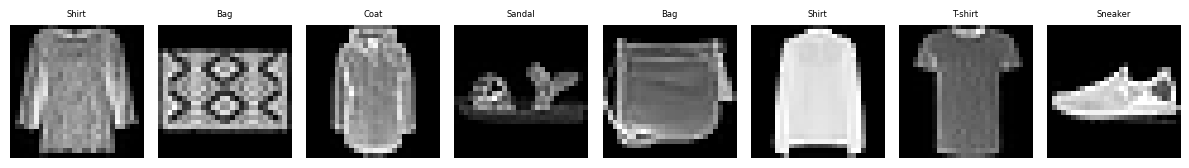

In [6]:

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_data = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_data  = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'train: {len(train_data)}  test: {len(test_data)}')

imgs, labels = next(iter(train_loader))
class_names = ['T-shirt','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(imgs[i].squeeze(), cmap='gray')
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Vanilla GAN - Generator and Discriminator

In [7]:
class VanillaGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(VanillaGenerator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 784),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z).view(-1, 1, 28, 28)


class VanillaDiscriminator(nn.Module):
    def __init__(self):
        super(VanillaDiscriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)

### DCGAN - Generator and Discriminator

In [8]:
class DCGenerator(nn.Module):
    def __init__(self, latent_dim):
        super(DCGenerator, self).__init__()
        self.net = nn.Sequential(
            # latent -> 7x7x256
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            # 7x7 -> 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # 14x14 -> 28x28
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.net(z)


class DCDiscriminator(nn.Module):
    def __init__(self):
        super(DCDiscriminator, self).__init__()
        self.net = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14x14 -> 7x7
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7x7 -> 1x1
            nn.Conv2d(128, 1, 7, 1, 0, bias=False)
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

### Loss Functions - BCE, LSGAN, WGAN

In [9]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

def disc_loss(real_out, fake_out, loss_type):
    if loss_type == 'bce':
        real_loss = bce(real_out, torch.ones_like(real_out))
        fake_loss = bce(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'lsgan':
        real_loss = mse(real_out, torch.ones_like(real_out))
        fake_loss = mse(fake_out, torch.zeros_like(fake_out))
        return (real_loss + fake_loss) / 2
    elif loss_type == 'wgan':
        return -(real_out.mean() - fake_out.mean())

def gen_loss(fake_out, loss_type):
    if loss_type == 'bce':
        return bce(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'lsgan':
        return mse(fake_out, torch.ones_like(fake_out))
    elif loss_type == 'wgan':
        return -fake_out.mean()

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=2e-4, betas=(0.5, 0.999))
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)
    else:
        return optim.RMSprop(model.parameters(), lr=5e-5)

### Training Loop

In [11]:
def train_epoch(G, D, loader, opt_g, opt_d, loss_type):
    G.train(); D.train()
    g_running = 0
    d_running = 0

    for real, _ in loader:
        real = real.to(DEVICE)
        bs   = real.size(0)

        # train discriminator
        z         = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake      = G(z).detach()
        real_out  = D(real)
        fake_out  = D(fake)
        d_loss    = disc_loss(real_out, fake_out, loss_type)
        opt_d.zero_grad()
        d_loss.backward()
        opt_d.step()

        # weight clipping for wgan
        if loss_type == 'wgan':
            for p in D.parameters():
                p.data.clamp_(-0.01, 0.01)

        # train generator
        z        = torch.randn(bs, LATENT_DIM).to(DEVICE)
        fake     = G(z)
        fake_out = D(fake)
        g_loss   = gen_loss(fake_out, loss_type)
        opt_g.zero_grad()
        g_loss.backward()
        opt_g.step()

        g_running += g_loss.item()
        d_running += d_loss.item()

    n = len(loader)
    return g_running / n, d_running / n

### Visualization

In [12]:
def show_generated(G, epoch, tag, n=16):
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, LATENT_DIM).to(DEVICE)
        imgs = G(z).cpu()
    imgs = (imgs + 1) / 2
    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle(f'epoch {epoch} - {tag}', fontsize=9)
    plt.tight_layout()
    plt.show()
    return fig

### Main Experiment Runner

In [13]:
results       = {}
saved_generators = {}

def run_experiment(arch, loss_type, opt_name):
    name = f'{arch}_{loss_type}_{opt_name}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type, 'optimizer': opt_name, 'epochs': EPOCHS
    })

    if arch == 'vanilla':
        G = VanillaGenerator(LATENT_DIM).to(DEVICE)
        D = VanillaDiscriminator().to(DEVICE)
    else:
        G = DCGenerator(LATENT_DIM).to(DEVICE)
        D = DCDiscriminator().to(DEVICE)

    opt_g = get_optimizer(G, opt_name)
    opt_d = get_optimizer(D, opt_name)

    g_losses = []
    d_losses = []

    for epoch in range(1, EPOCHS + 1):
        g_loss, d_loss = train_epoch(G, D, train_loader, opt_g, opt_d, loss_type)
        g_losses.append(g_loss)
        d_losses.append(d_loss)
        wandb.log({'epoch': epoch, 'g_loss': g_loss, 'd_loss': d_loss})
        print(f'  epoch {epoch}/{EPOCHS}  g_loss={g_loss:.4f}  d_loss={d_loss:.4f}')

        if epoch % 5 == 0 or epoch == EPOCHS:
            fig = show_generated(G, epoch, name)
            wandb.log({f'generated_ep{epoch}': wandb.Image(fig)})
            plt.close(fig)

    # loss curves
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(g_losses, label='generator')
    ax.plot(d_losses, label='discriminator')
    ax.set_xlabel('epoch')
    ax.set_ylabel('loss')
    ax.set_title(name)
    ax.legend()
    plt.tight_layout()
    plt.show()
    wandb.log({'loss_curve': wandb.Image(fig)})
    plt.close(fig)

    torch.save(G.state_dict(), f'{name}_G.pt')
    torch.save(D.state_dict(), f'{name}_D.pt')
    saved_generators[name] = G
    results[name] = {'g_loss': g_losses[-1], 'd_loss': d_losses[-1]}

    wandb.finish()
    return G, D

### Quick Test - run this first


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1590  d_loss=0.4770
  epoch 2/5  g_loss=1.8085  d_loss=0.4653
  epoch 3/5  g_loss=1.9313  d_loss=0.4617
  epoch 4/5  g_loss=1.7289  d_loss=0.4893
  epoch 5/5  g_loss=1.5879  d_loss=0.5062


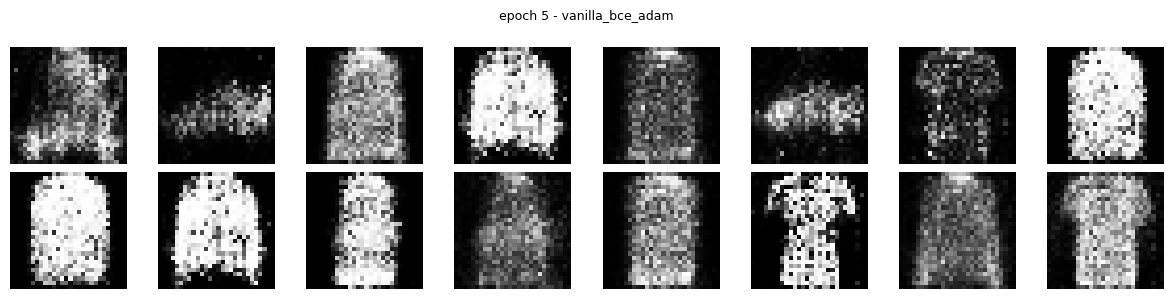

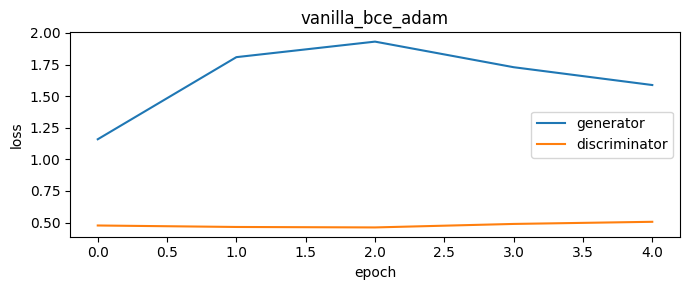

d_loss,▃▂▁▅█
epoch,▁▃▅▆█
g_loss,▁▇█▆▅
d_loss,0.50624
epoch,5
g_loss,1.58794



starting: dcgan_bce_adam


  epoch 1/5  g_loss=2.1346  d_loss=0.3040
  epoch 2/5  g_loss=1.3396  d_loss=0.4197
  epoch 3/5  g_loss=1.1728  d_loss=0.4956
  epoch 4/5  g_loss=1.1041  d_loss=0.5274
  epoch 5/5  g_loss=1.1045  d_loss=0.5264


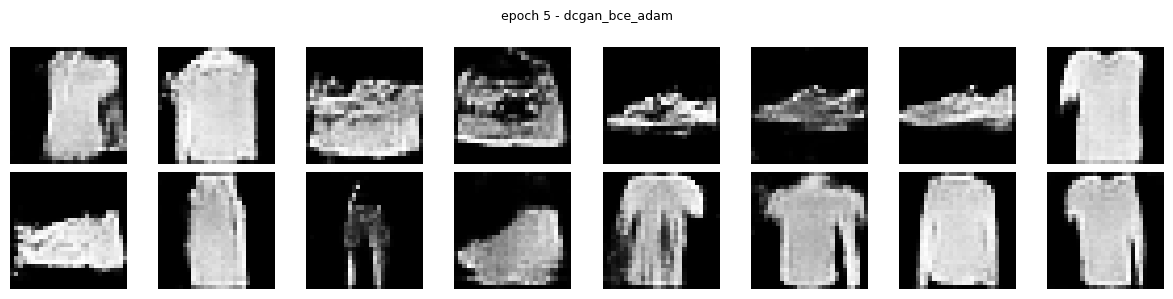

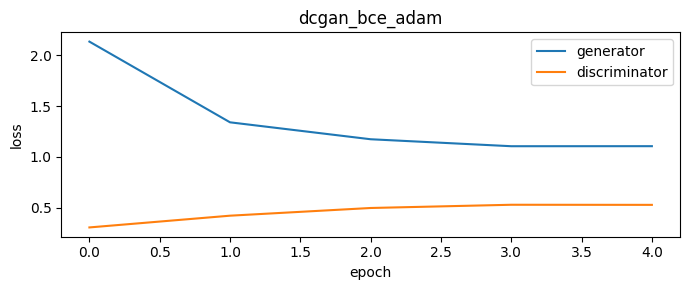

d_loss,▁▅▇██
epoch,▁▃▅▆█
g_loss,█▃▁▁▁
d_loss,0.52643
epoch,5
g_loss,1.10452


(DCGenerator(
   (net): Sequential(
     (0): ConvTranspose2d(100, 256, kernel_size=(7, 7), stride=(1, 1), bias=False)
     (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (2): ReLU(inplace=True)
     (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (5): ReLU(inplace=True)
     (6): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (7): Tanh()
   )
 ),
 DCDiscriminator(
   (net): Sequential(
     (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (1): LeakyReLU(negative_slope=0.2, inplace=True)
     (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
     (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (4): LeakyReLU(negative_slope=0.2, inplace=True)
    

In [14]:
run_experiment('vanilla', 'bce', 'adam')
run_experiment('dcgan',   'bce', 'adam')

### Full Grid - all combinations


starting: vanilla_bce_adam


  epoch 1/5  g_loss=1.1067  d_loss=0.4949
  epoch 2/5  g_loss=1.8136  d_loss=0.4511
  epoch 3/5  g_loss=1.7917  d_loss=0.4848
  epoch 4/5  g_loss=1.4498  d_loss=0.5374
  epoch 5/5  g_loss=1.4145  d_loss=0.5448


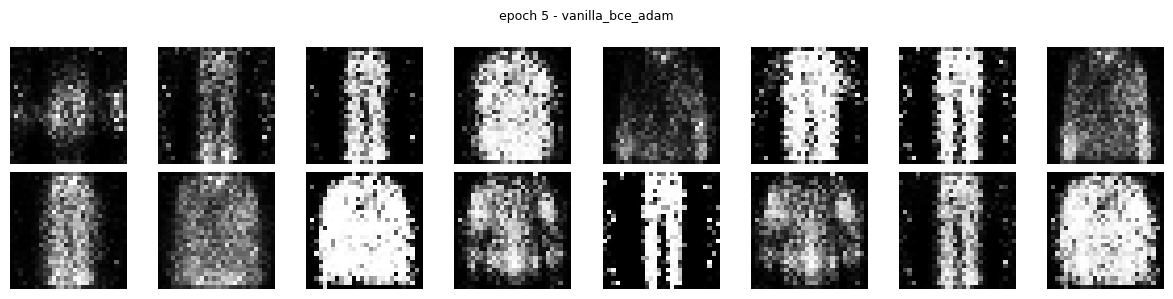

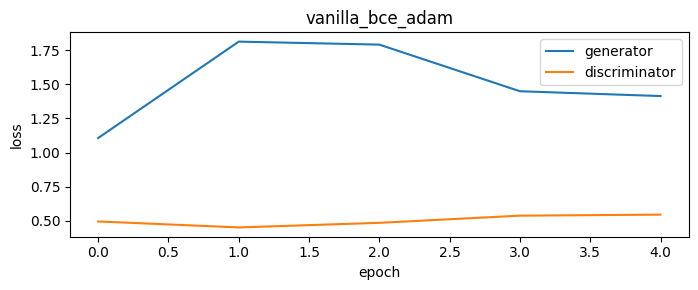

d_loss,▄▁▄▇█
epoch,▁▃▅▆█
g_loss,▁██▄▄
d_loss,0.54484
epoch,5
g_loss,1.41446



starting: vanilla_bce_sgd


  epoch 1/5  g_loss=0.7830  d_loss=0.3830
  epoch 2/5  g_loss=1.5377  d_loss=0.2895
  epoch 3/5  g_loss=2.4099  d_loss=0.1597
  epoch 4/5  g_loss=2.7100  d_loss=0.1563
  epoch 5/5  g_loss=2.9997  d_loss=0.2103


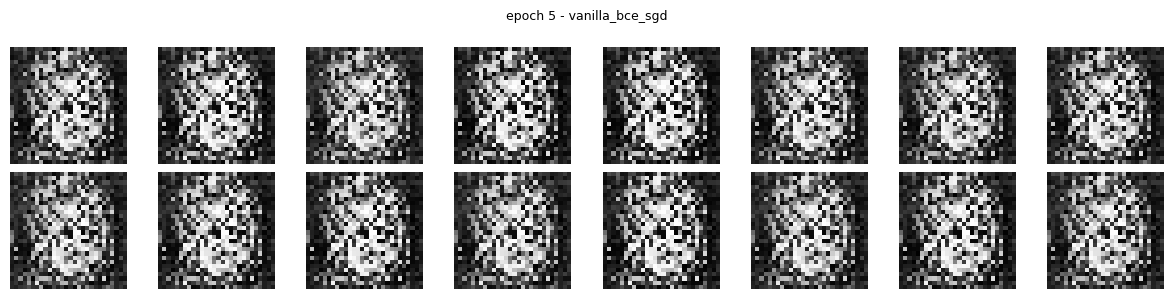

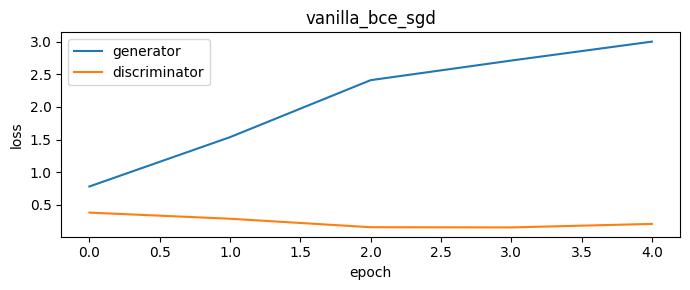

d_loss,█▅▁▁▃
epoch,▁▃▅▆█
g_loss,▁▃▆▇█
d_loss,0.21027
epoch,5
g_loss,2.99966



starting: vanilla_bce_rmsprop


  epoch 1/5  g_loss=0.8379  d_loss=0.4713
  epoch 2/5  g_loss=1.4070  d_loss=0.3605
  epoch 3/5  g_loss=2.0867  d_loss=0.2926
  epoch 4/5  g_loss=2.5282  d_loss=0.2529
  epoch 5/5  g_loss=2.6496  d_loss=0.2633


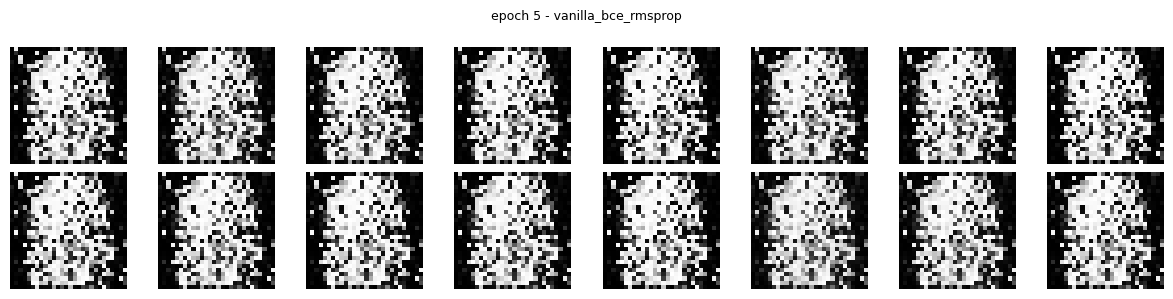

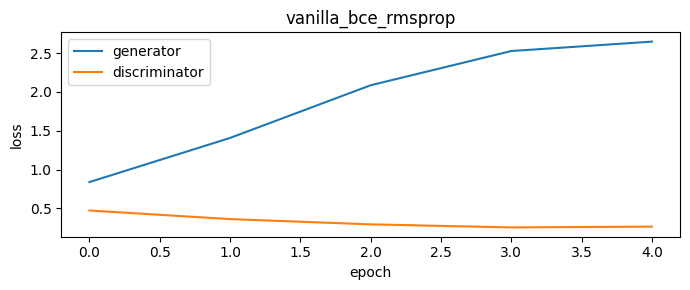

d_loss,█▄▂▁▁
epoch,▁▃▅▆█
g_loss,▁▃▆██
d_loss,0.26326
epoch,5
g_loss,2.64964



starting: vanilla_lsgan_adam


  epoch 1/5  g_loss=1.0134  d_loss=0.0682
  epoch 2/5  g_loss=0.8180  d_loss=0.1206
  epoch 3/5  g_loss=0.6532  d_loss=0.1524
  epoch 4/5  g_loss=0.6390  d_loss=0.1548
  epoch 5/5  g_loss=0.5844  d_loss=0.1695


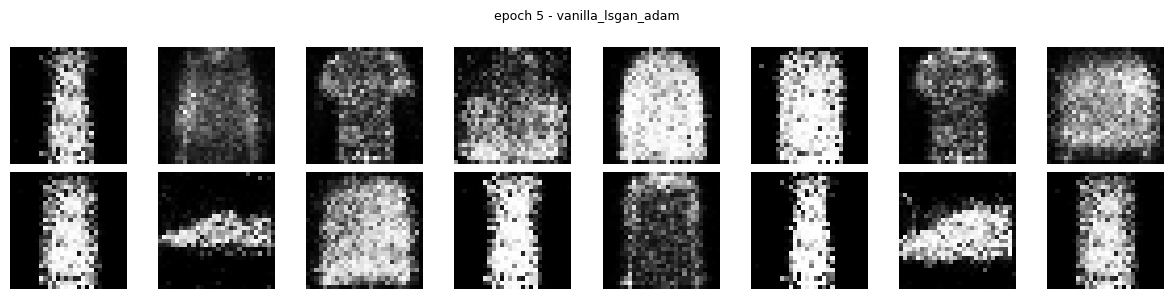

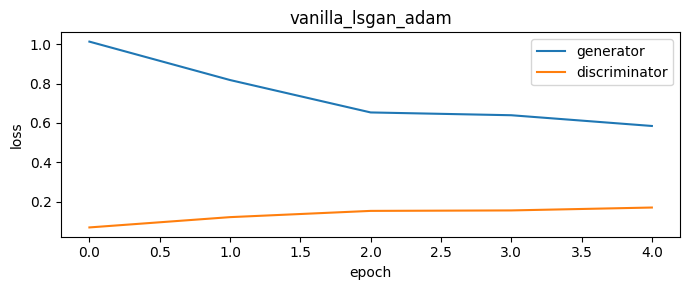

d_loss,▁▅▇▇█
epoch,▁▃▅▆█
g_loss,█▅▂▂▁
d_loss,0.16947
epoch,5
g_loss,0.58435



starting: vanilla_lsgan_sgd


  epoch 1/5  g_loss=0.7238  d_loss=0.0401
  epoch 2/5  g_loss=0.9845  d_loss=0.0336
  epoch 3/5  g_loss=0.9712  d_loss=0.0234
  epoch 4/5  g_loss=0.9692  d_loss=0.0248
  epoch 5/5  g_loss=0.9696  d_loss=0.0259


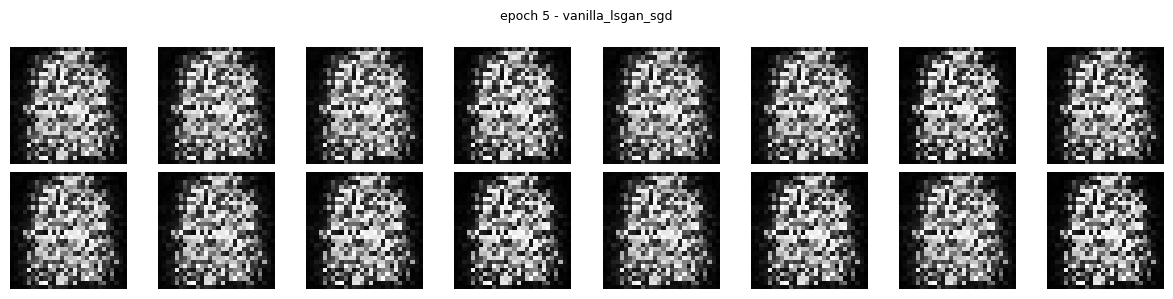

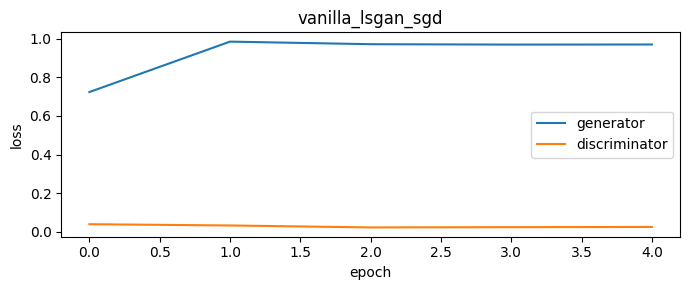

d_loss,█▅▁▂▂
epoch,▁▃▅▆█
g_loss,▁████
d_loss,0.02591
epoch,5
g_loss,0.96965



starting: vanilla_lsgan_rmsprop


  epoch 1/5  g_loss=0.8801  d_loss=0.0679
  epoch 2/5  g_loss=0.9634  d_loss=0.0736
  epoch 3/5  g_loss=0.9328  d_loss=0.0795
  epoch 4/5  g_loss=0.9407  d_loss=0.0872
  epoch 5/5  g_loss=0.9369  d_loss=0.0835


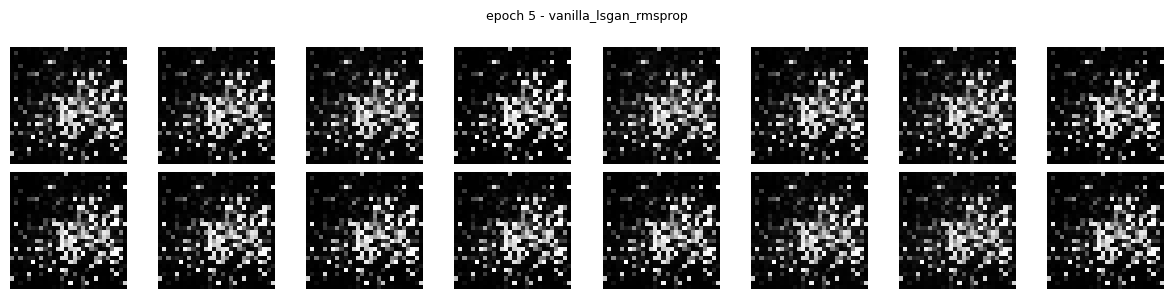

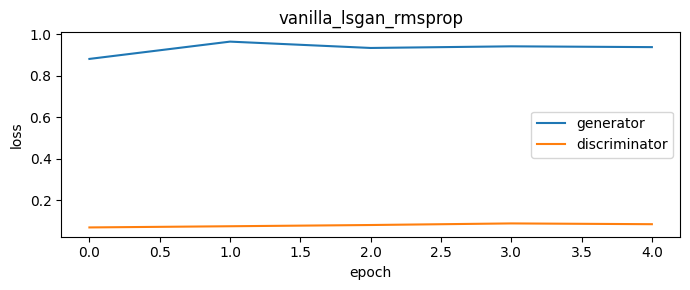

d_loss,▁▃▅█▇
epoch,▁▃▅▆█
g_loss,▁█▅▆▆
d_loss,0.08349
epoch,5
g_loss,0.93688



starting: vanilla_wgan_adam


  epoch 1/5  g_loss=-0.4614  d_loss=-0.4004
  epoch 2/5  g_loss=-0.1267  d_loss=-0.2113
  epoch 3/5  g_loss=0.0297  d_loss=-0.1074
  epoch 4/5  g_loss=-0.2582  d_loss=-0.2630
  epoch 5/5  g_loss=-0.4599  d_loss=-0.4154


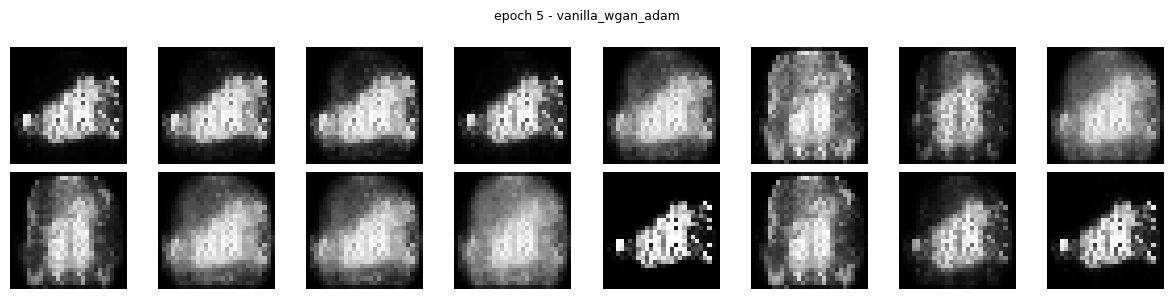

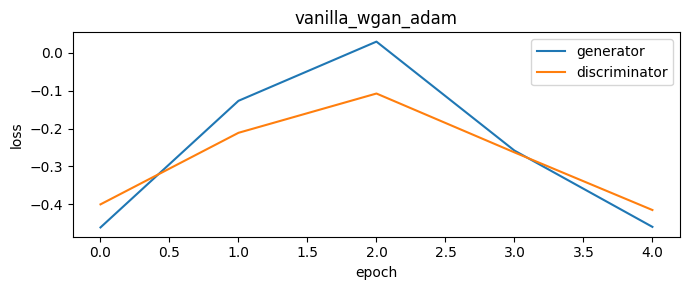

d_loss,▁▆█▄▁
epoch,▁▃▅▆█
g_loss,▁▆█▄▁
d_loss,-0.41537
epoch,5
g_loss,-0.45992



starting: vanilla_wgan_sgd


  epoch 1/5  g_loss=0.1479  d_loss=-1.8742
  epoch 2/5  g_loss=2.2767  d_loss=-0.6533
  epoch 3/5  g_loss=2.6389  d_loss=-0.8121
  epoch 4/5  g_loss=-1.1202  d_loss=-2.6364
  epoch 5/5  g_loss=2.6562  d_loss=-1.0180


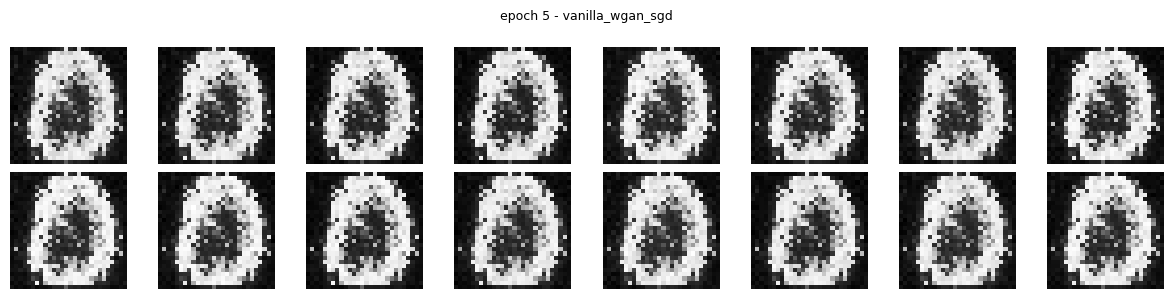

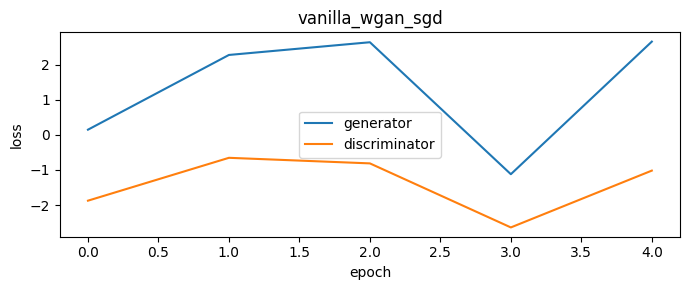

d_loss,▄█▇▁▇
epoch,▁▃▅▆█
g_loss,▃▇█▁█
d_loss,-1.018
epoch,5
g_loss,2.65624



starting: vanilla_wgan_rmsprop


  epoch 1/5  g_loss=-0.0276  d_loss=-0.1701
  epoch 2/5  g_loss=-0.0688  d_loss=-0.2661
  epoch 3/5  g_loss=-0.4238  d_loss=-0.2613
  epoch 4/5  g_loss=-0.5753  d_loss=-0.4158
  epoch 5/5  g_loss=-0.3421  d_loss=-0.4051


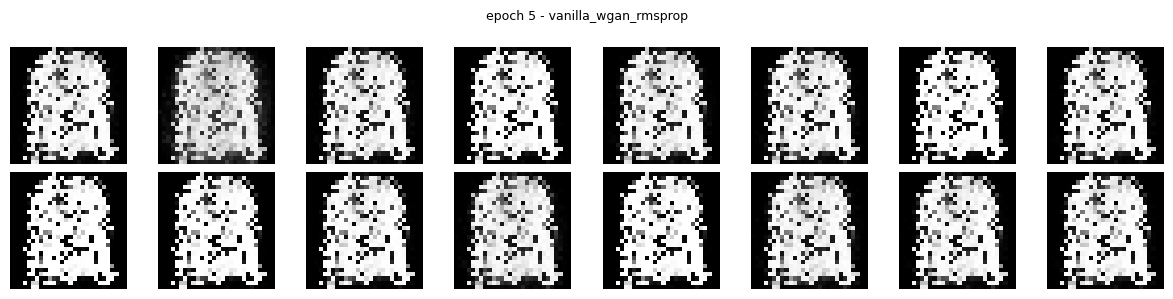

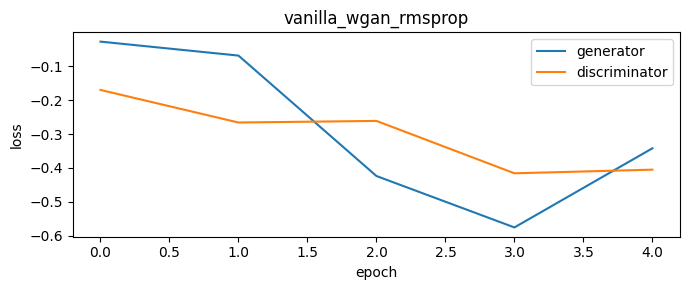

d_loss,█▅▅▁▁
epoch,▁▃▅▆█
g_loss,█▇▃▁▄
d_loss,-0.40507
epoch,5
g_loss,-0.34206



starting: dcgan_bce_adam


  epoch 1/5  g_loss=2.9172  d_loss=0.2576
  epoch 2/5  g_loss=1.3987  d_loss=0.4090
  epoch 3/5  g_loss=1.3527  d_loss=0.4556
  epoch 4/5  g_loss=1.4122  d_loss=0.4679
  epoch 5/5  g_loss=1.1667  d_loss=0.5053


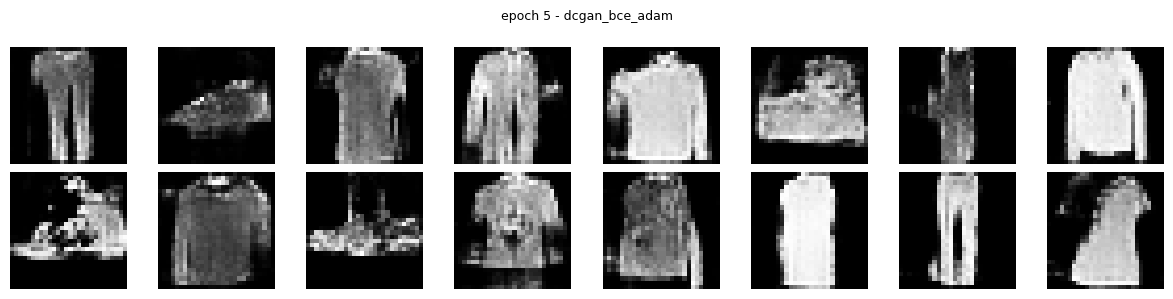

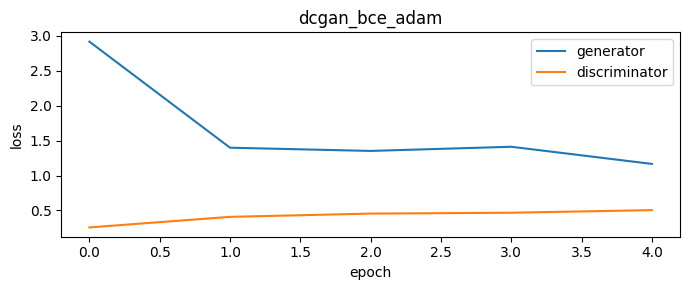

d_loss,▁▅▇▇█
epoch,▁▃▅▆█
g_loss,█▂▂▂▁
d_loss,0.5053
epoch,5
g_loss,1.16674



starting: dcgan_bce_sgd


  epoch 1/5  g_loss=6.3195  d_loss=0.0316
  epoch 2/5  g_loss=7.7033  d_loss=0.0011
  epoch 3/5  g_loss=8.0755  d_loss=0.0007
  epoch 4/5  g_loss=8.5526  d_loss=0.0004
  epoch 5/5  g_loss=7.8426  d_loss=0.0017


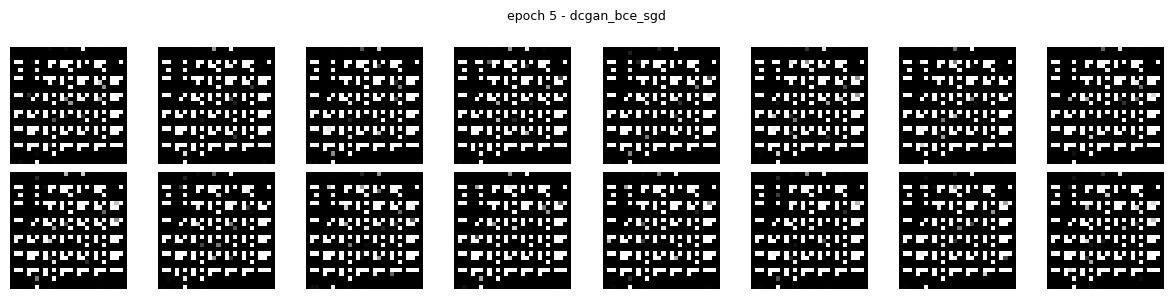

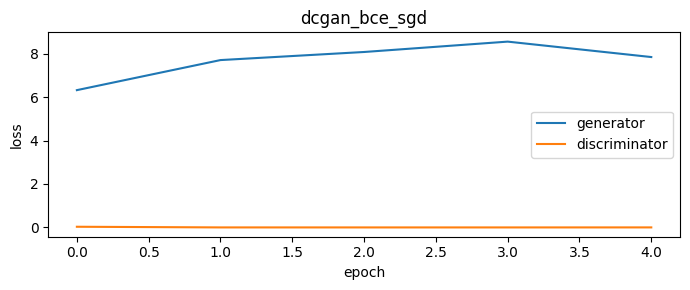

d_loss,█▁▁▁▁
epoch,▁▃▅▆█
g_loss,▁▅▇█▆
d_loss,0.00169
epoch,5
g_loss,7.84257



starting: dcgan_bce_rmsprop


  epoch 1/5  g_loss=2.0650  d_loss=0.2969
  epoch 2/5  g_loss=1.6398  d_loss=0.2752
  epoch 3/5  g_loss=1.7635  d_loss=0.2614
  epoch 4/5  g_loss=1.5997  d_loss=0.3136
  epoch 5/5  g_loss=1.5023  d_loss=0.3470


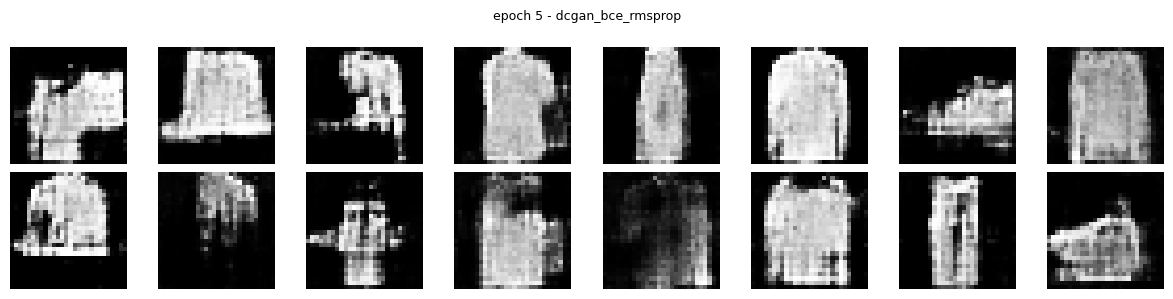

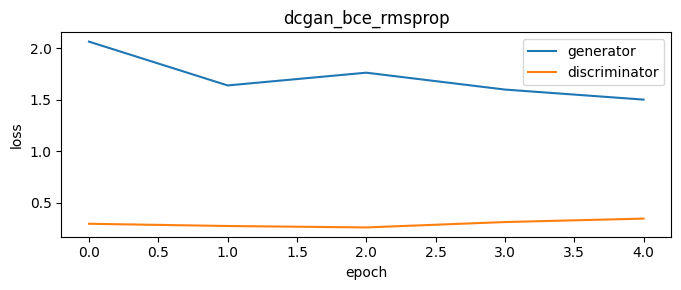

d_loss,▄▂▁▅█
epoch,▁▃▅▆█
g_loss,█▃▄▂▁
d_loss,0.34698
epoch,5
g_loss,1.50229



starting: dcgan_lsgan_adam


  epoch 1/5  g_loss=0.7218  d_loss=0.1539
  epoch 2/5  g_loss=0.6117  d_loss=0.1213
  epoch 3/5  g_loss=0.5316  d_loss=0.1561
  epoch 4/5  g_loss=0.4985  d_loss=0.1735
  epoch 5/5  g_loss=0.4675  d_loss=0.1812


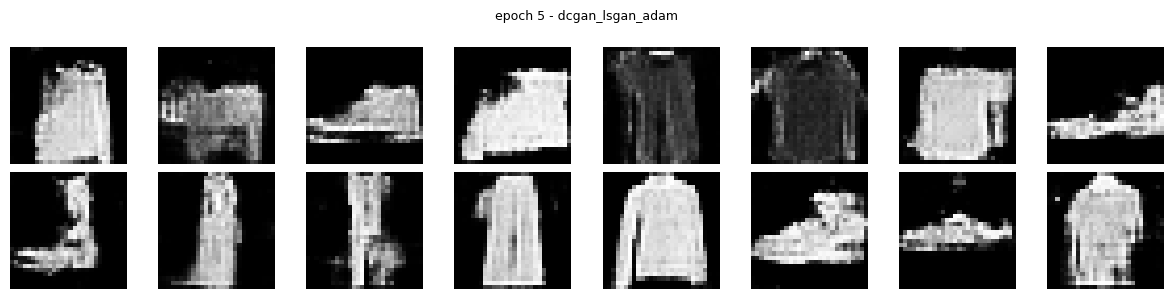

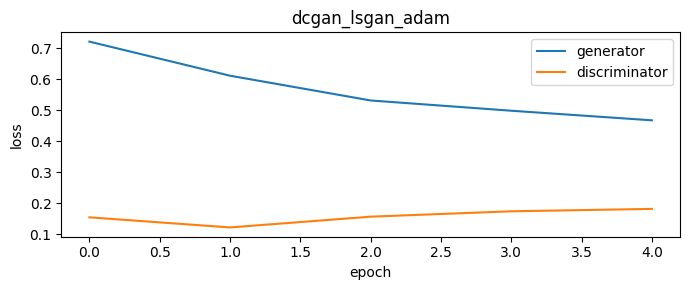

d_loss,▅▁▅▇█
epoch,▁▃▅▆█
g_loss,█▅▃▂▁
d_loss,0.18119
epoch,5
g_loss,0.46749



starting: dcgan_lsgan_sgd


  epoch 1/5  g_loss=1.1575  d_loss=0.0734
  epoch 2/5  g_loss=1.0256  d_loss=0.0071
  epoch 3/5  g_loss=1.0082  d_loss=0.0029
  epoch 4/5  g_loss=1.0027  d_loss=0.0018
  epoch 5/5  g_loss=1.0025  d_loss=0.0018


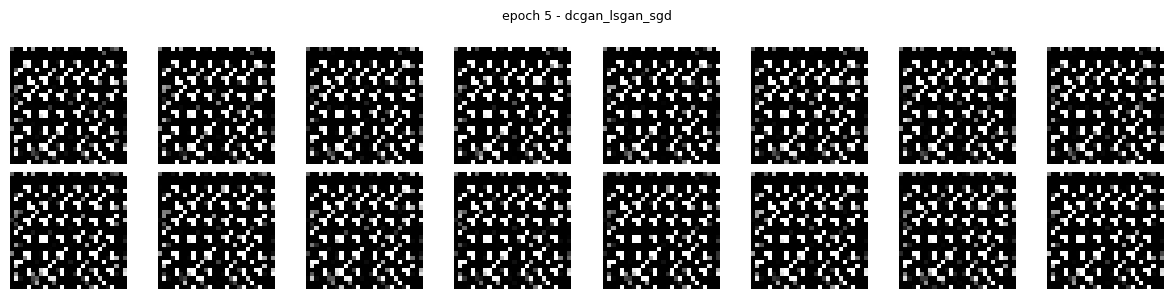

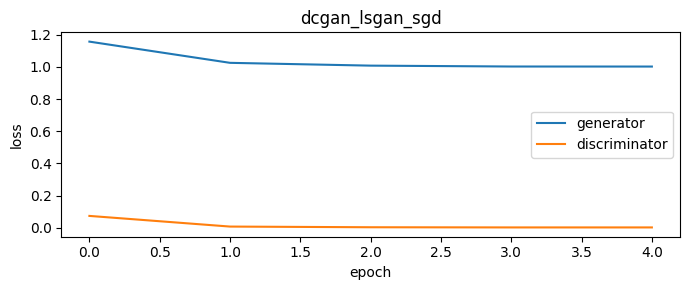

d_loss,█▂▁▁▁
epoch,▁▃▅▆█
g_loss,█▂▁▁▁
d_loss,0.00177
epoch,5
g_loss,1.00245



starting: dcgan_lsgan_rmsprop


  epoch 1/5  g_loss=1.0144  d_loss=0.0490
  epoch 2/5  g_loss=1.0135  d_loss=0.0195
  epoch 3/5  g_loss=1.0104  d_loss=0.0150
  epoch 4/5  g_loss=1.0221  d_loss=0.0163
  epoch 5/5  g_loss=1.0261  d_loss=0.0161


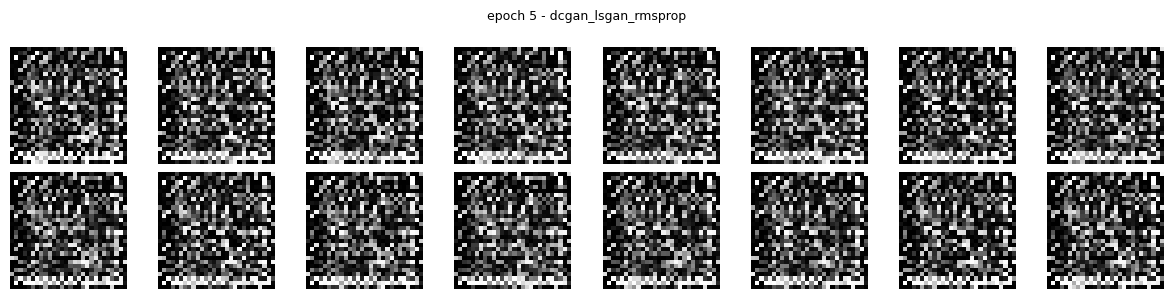

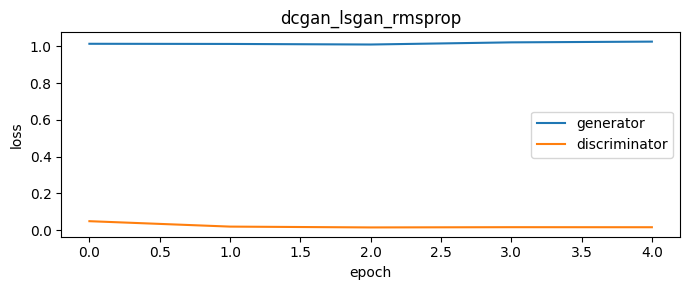

d_loss,█▂▁▁▁
epoch,▁▃▅▆█
g_loss,▃▂▁▆█
d_loss,0.01606
epoch,5
g_loss,1.02614



starting: dcgan_wgan_adam


  epoch 1/5  g_loss=-0.0021  d_loss=-0.0009
  epoch 2/5  g_loss=0.0026  d_loss=-0.0043
  epoch 3/5  g_loss=-0.0044  d_loss=-0.0064
  epoch 4/5  g_loss=-0.0085  d_loss=-0.0054
  epoch 5/5  g_loss=-0.0092  d_loss=-0.0042


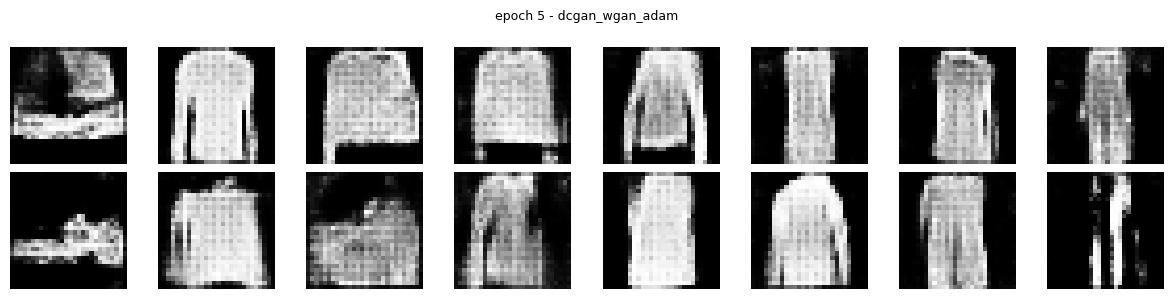

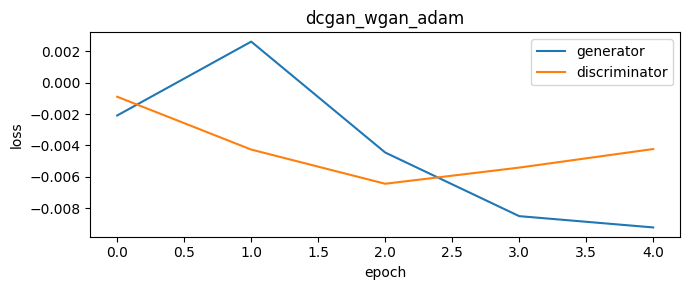

d_loss,█▄▁▂▄
epoch,▁▃▅▆█
g_loss,▅█▄▁▁
d_loss,-0.00423
epoch,5
g_loss,-0.00923



starting: dcgan_wgan_sgd


  epoch 1/5  g_loss=0.2783  d_loss=-0.4935
  epoch 2/5  g_loss=0.4810  d_loss=-0.8780
  epoch 3/5  g_loss=0.4828  d_loss=-0.9027
  epoch 4/5  g_loss=0.4768  d_loss=-0.8826
  epoch 5/5  g_loss=0.4497  d_loss=-0.7767


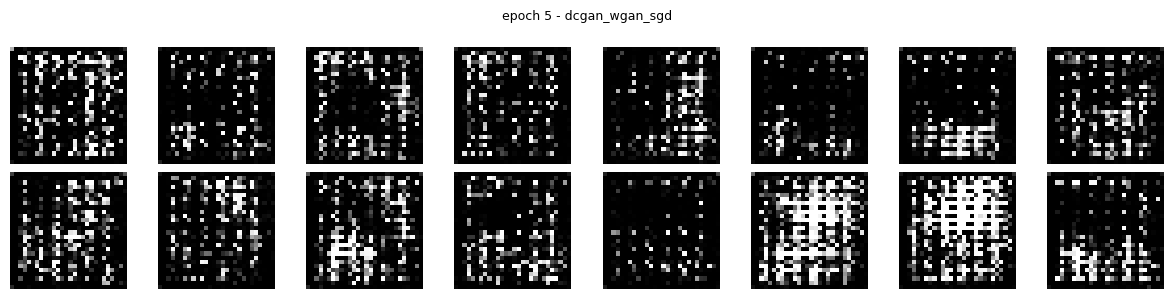

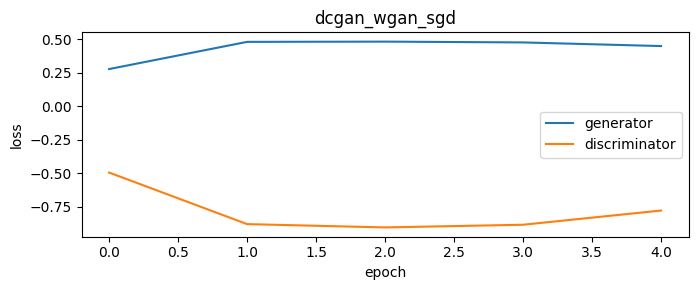

d_loss,█▁▁▁▃
epoch,▁▃▅▆█
g_loss,▁███▇
d_loss,-0.77672
epoch,5
g_loss,0.44968



starting: dcgan_wgan_rmsprop


  epoch 1/5  g_loss=0.1021  d_loss=-0.1700
  epoch 2/5  g_loss=0.4069  d_loss=-0.5968
  epoch 3/5  g_loss=0.4414  d_loss=-0.6382
  epoch 4/5  g_loss=0.1264  d_loss=-0.2885
  epoch 5/5  g_loss=-0.0478  d_loss=-0.0193


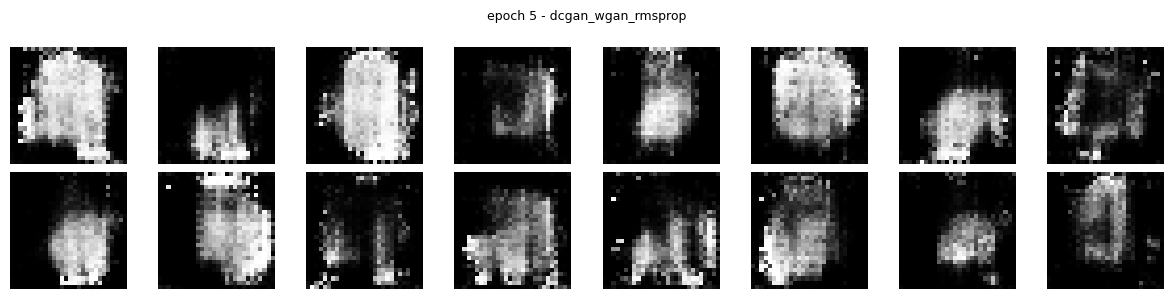

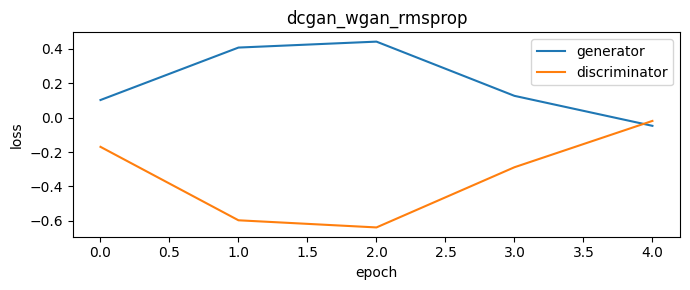

d_loss,▆▁▁▅█
epoch,▁▃▅▆█
g_loss,▃██▃▁
d_loss,-0.01933
epoch,5
g_loss,-0.04783


In [15]:
for arch in MODELS:
    for lf in LOSS_FNS:
        for opt in OPTIMIZERS:
            run_experiment(arch, lf, opt)

### Results Summary

In [16]:
print(f'{"config":<35} {"g_loss":>10} {"d_loss":>10}')
print('-' * 57)
for k, v in sorted(results.items(), key=lambda x: x[1]['g_loss']):
    print(f'{k:<35} {v["g_loss"]:>10.4f} {v["d_loss"]:>10.4f}')

config                                  g_loss     d_loss
---------------------------------------------------------
vanilla_wgan_adam                      -0.4599    -0.4154
vanilla_wgan_rmsprop                   -0.3421    -0.4051
dcgan_wgan_rmsprop                     -0.0478    -0.0193
dcgan_wgan_adam                        -0.0092    -0.0042
dcgan_wgan_sgd                          0.4497    -0.7767
dcgan_lsgan_adam                        0.4675     0.1812
vanilla_lsgan_adam                      0.5844     0.1695
vanilla_lsgan_rmsprop                   0.9369     0.0835
vanilla_lsgan_sgd                       0.9696     0.0259
dcgan_lsgan_sgd                         1.0025     0.0018
dcgan_lsgan_rmsprop                     1.0261     0.0161
dcgan_bce_adam                          1.1667     0.5053
vanilla_bce_adam                        1.4145     0.5448
dcgan_bce_rmsprop                       1.5023     0.3470
vanilla_bce_rmsprop                     2.6496     0.2633
vanilla_wgan_s

### Upload to HuggingFace

In [17]:
from huggingface_hub import login
login()

In [18]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_generators.keys():
    for suffix in ['_G.pt', '_D.pt']:
        fname = f'{name}{suffix}'
        if os.path.exists(fname):
            api.upload_file(
                path_or_fileobj=fname,
                path_in_repo=f'models/{fname}',
                repo_id=HF_REPO
            )
            print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  vanilla_bce_adam_G.pt       :   9%|9         |  554kB / 5.95MB            

uploaded: vanilla_bce_adam_G.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

...

uploaded: dcgan_wgan_rmsprop_G.pt


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  dcgan_wgan_rmsprop_D.pt     : 100%|##########|  559kB /  559kB            

uploaded: dcgan_wgan_rmsprop_D.pt
https://huggingface.co/MAKSWE/exp9-gans


In [19]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/ayanmdkhan2340-delhi-technological-university/exp9-gans
HF  : https://huggingface.co/MAKSWE/exp9-gans
